## Comparative Multi-Team EDA

---
## Step 1 - Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

TITLE_TEAMS = ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']

TEAM_PALETTE = {
    'Arsenal':            '#EF0107',
    'Liverpool':          '#00B2A9',
    'Manchester City':    '#6CABDD',
    'Manchester United':  '#FFB81C',
}

STAKES_PALETTE = {'High Stakes': '#EF0107', 'Normal': '#9C824A'}

SEASON_LABELS = {
    1920: '19-20', 2021: '20-21', 2122: '21-22',
    2223: '22-23', 2324: '23-24', 2425: '24-25', 2526: '25-26'
}

BIG6 = {'Arsenal', 'Liverpool', 'Manchester City', 'Manchester United', 'Chelsea', 'Tottenham'}

print('Imports ready')

Imports ready


---
## Step 2 - Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(PROC_DATA_DIR / 'all_4teams_processed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['team', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Teams: {sorted(df["team"].unique())}')

Shape: (1064, 37)
Teams: ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']


---
## Quick Data Overview

In [3]:
# check is_high_stakes_retro sits at 10/38 per team-season
# check mean stakes_intensity within the retro bucket per team-season (absolute-intensity caveat)
retro_counts = df.groupby(['team','season'])['is_high_stakes_retro'].sum().unstack()
print('is_high_stakes_retro matches per team per season (should all read 10): ')
print(retro_counts)

is_high_stakes_retro matches per team per season (should all read 10): 
season             1920  2021  2122  2223  2324  2425  2526
team                                                       
Arsenal              10    10    10    10    10    10    10
Liverpool            10    10    10    10    10    10    10
Manchester City      10    10    10    10    10    10    10
Manchester United    10    10    10    10    10    10    10


In [4]:
hs = df[df['is_high_stakes_retro']]
intensity_within_bucket = hs.groupby(['team','season'])['stakes_intensity'].mean().unstack()
print('Mean stakes_intensity within the retro high-stakes bucket, per team-season:')
print(intensity_within_bucket.round(3))

Mean stakes_intensity within the retro high-stakes bucket, per team-season:
season              1920   2021   2122   2223   2324   2425   2526
team                                                              
Arsenal            0.464  0.443  0.629  0.825  0.850  0.684  0.964
Liverpool          0.956  0.623  0.851  0.502  0.825  0.955  0.658
Manchester City    0.663  0.946  0.956  0.935  0.947  0.660  0.786
Manchester United  0.651  0.664  0.551  0.541  0.492  0.364  0.650


---
## Section B - Is the Bottle Gap Unique to Arsenal?

---
## Chart B1 - The Bottle Gap Matrix (All Four Teams)

This is the same computation as NB03's Chart C5, high-stakes PPG minus season-baseline PPG, now run once per team instead of once for Arsenal. One subplot per team so the four patterns sit side by side.

In [5]:
# high-stakes-retro PPG minus season-baseline PPG, per team per season
# 2x2 grid of subplots, one per team
season_ppg = df.groupby(['team', 'season'])['points'].mean()
hs_ppg = df[df['is_high_stakes_retro']].groupby(['team', 'season'])['points'].mean()

ppg_gap = pd.concat([season_ppg.rename('season_ppg'), hs_ppg.rename('hs_ppg')], axis=1)
ppg_gap['gap'] = ppg_gap['hs_ppg'] - ppg_gap['season_ppg']
ppg_gap = ppg_gap.reset_index()
ppg_gap['season_label'] = ppg_gap['season'].map(SEASON_LABELS)

print(ppg_gap.round(3).to_string(index=False))

             team  season  season_ppg  hs_ppg    gap season_label
          Arsenal    1920       1.474     1.7  0.226        19-20
          Arsenal    2021       1.605     1.8  0.195        20-21
          Arsenal    2122       1.816     1.2 -0.616        21-22
          Arsenal    2223       2.211     2.1 -0.111        22-23
          Arsenal    2324       2.342     2.5  0.158        23-24
          Arsenal    2425       1.947     1.9 -0.047        24-25
          Arsenal    2526       2.237     2.4  0.163        25-26
        Liverpool    1920       2.605     2.0 -0.605        19-20
        Liverpool    2021       1.816     2.0  0.184        20-21
        Liverpool    2122       2.421     2.6  0.179        21-22
        Liverpool    2223       1.763     2.4  0.637        22-23
        Liverpool    2324       2.158     2.0 -0.158        23-24
        Liverpool    2425       2.211     1.7 -0.511        24-25
        Liverpool    2526       1.579     1.4 -0.179        25-26
  Manchest

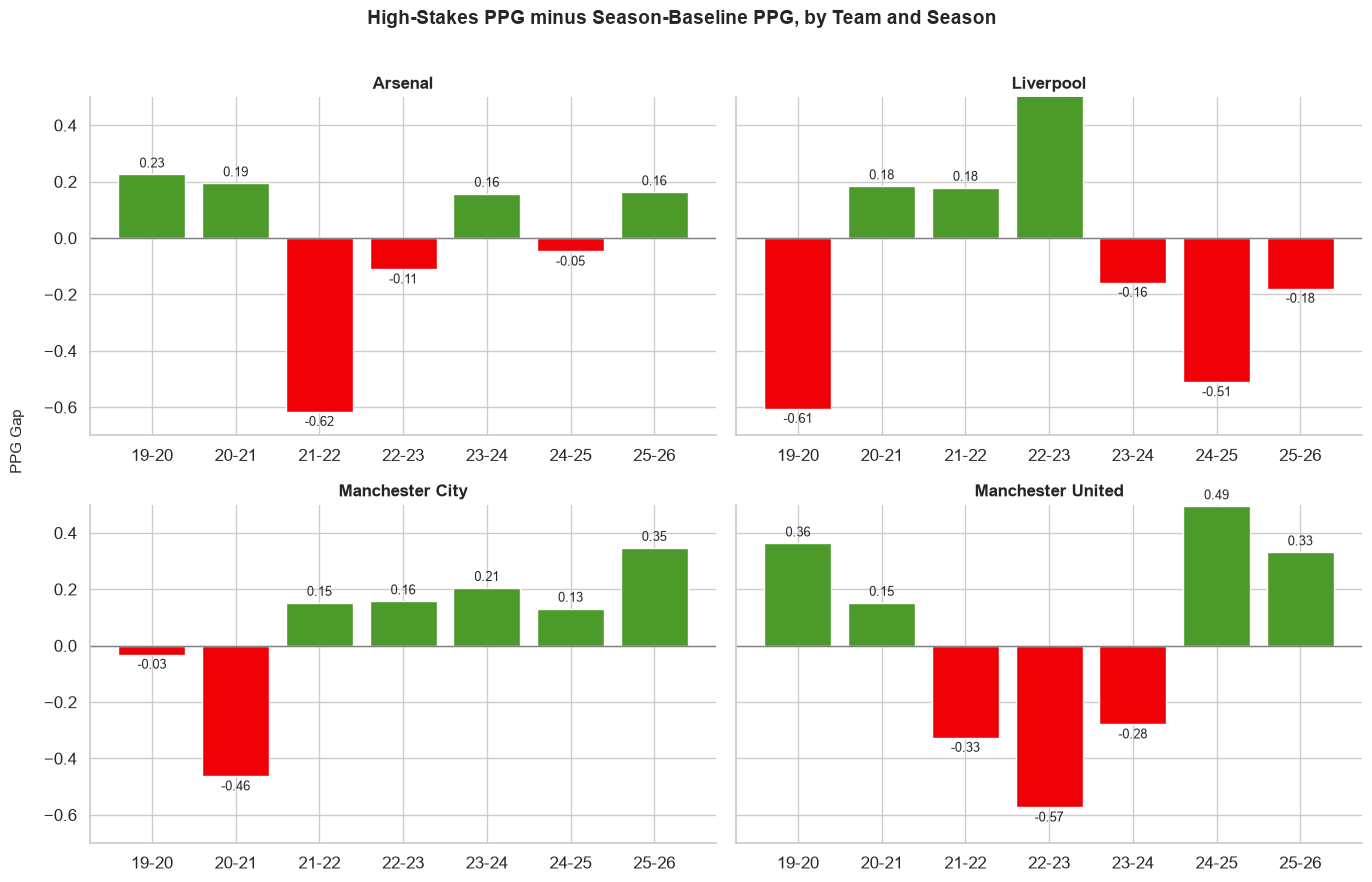

In [6]:
fig, axes = plt.subplots(2, 2, figsize = (14,9), sharey = True)

for ax, team in zip(axes.flat, TITLE_TEAMS):
    team_df = ppg_gap[ppg_gap['team'] == team].sort_values('season')
    colors = ['#EF0107' if g < 0 else '#4C9A2A' for g in team_df['gap']]
    bars = ax.bar(team_df['season_label'], team_df['gap'], color = colors)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.axhline(y=0, color='grey', linewidth=1)
    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.7, 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('High-Stakes PPG minus Season-Baseline PPG, by Team and Season',
             fontsize=14, fontweight='bold')
fig.text(0.02, 0.5, 'PPG Gap', va='center', rotation='vertical', fontsize=11)
plt.tight_layout(rect=[0.03, 0, 1, 0.97])
plt.show()

### Reading Chart B1

Arsenal's own pattern from NB03 is still here: negative in 22-23 and 24-25, positive in 23-24 and 25-26. It is not the only team with negative bars though. Liverpool has a large negative gap in 19-20 (-0.61) and again in 24-25 (-0.51). Manchester United swings negative across several of its mid-career seasons. Manchester City is the most consistently positive team, six of seven seasons above its own baseline.

So this is not a pattern unique to Arsenal in the sense that only Arsenal underperforms under pressure. Every team has seasons where high-stakes PPG dips below baseline. What is specific to Arsenal is that its two negative seasons line up exactly with the two seasons already labelled bottles, and its positive seasons line up with the title win and the non-bottle year. The other three teams' good and bad pressure seasons do not map as neatly onto anything written about them at the time, worth noting rather than assuming this framing generalises.

---
## Chart B2 - Pressure Resilience Index

One number per team, the average PPG gap across that team's contention seasons (seasons where the absolute is_high_stakes flag caught at least 5 matches, the same filter NB02 used for the Drop Index table). Ranks the four teams by how well their high-stakes PPG tracks their own baseline on average.

In [7]:
# mean PPG gap over contention seasons only (>=5 absolute high-stakes matches), per team
bucket_counts = (
    df.groupby(['team', 'season', 'is_high_stakes'])
    .size().unstack(fill_value=0)
    .rename(columns={False: 'n_normal', True: 'n_highstakes'})
)
contention = bucket_counts[bucket_counts['n_highstakes'] >= 5].reset_index()[['team', 'season']]

gap_contention = ppg_gap.merge(contention, on=['team', 'season'], how='inner')
resilience = gap_contention.groupby('team')['gap'].mean().sort_values(ascending=False)

print(bucket_counts)
print('Contention seasons per team:')
print(contention.groupby('team').size())
print()
print('Pressure Resilience Index (mean PPG gap, contention seasons only):')
print(resilience.round(3))

is_high_stakes            n_normal  n_highstakes
team              season                        
Arsenal           1920          35             3
                  2021          36             2
                  2122          30             8
                  2223          24            14
                  2324          23            15
                  2425          23            15
                  2526          21            17
Liverpool         1920          21            17
                  2021          25            13
                  2122          22            16
                  2223          35             3
                  2324          25            13
                  2425          20            18
                  2526          26            12
Manchester City   1920          25            13
                  2021          21            17
                  2122          20            18
                  2223          22            16
                  23

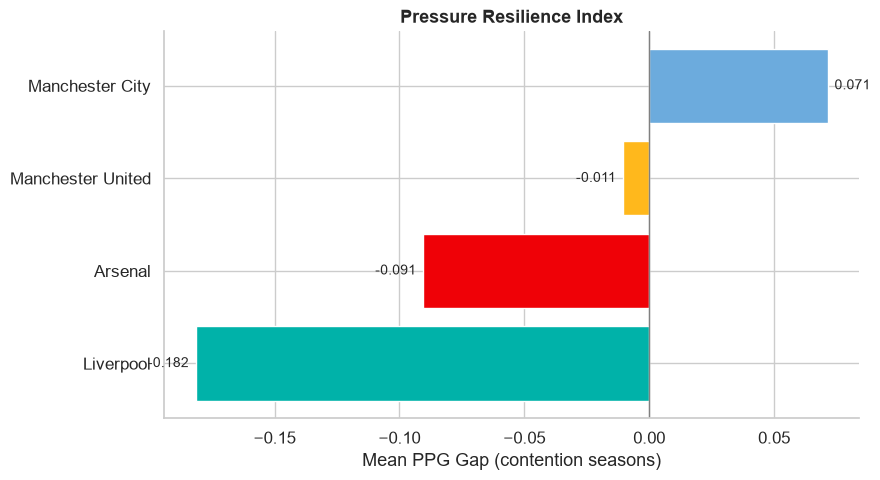

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = [TEAM_PALETTE[t] for t in resilience.index]
bars = ax.barh(resilience.index, resilience.values, color = colors)
ax.bar_label(bars, fmt = '%.3f', padding = 5, fontsize=10)
ax.axvline(x=0, color = 'grey', linewidth = 1)
ax.set_xlabel('Mean PPG Gap (contention seasons)')
ax.set_title('Pressure Resilience Index', fontsize = 13, fontweight = 'bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reading Chart B2

Manchester City is the only team with a positive average, +0.071. Manchester United sits close to flat at -0.011. Arsenal is at -0.091. Liverpool is the worst of the four by this measure, -0.182, driven mostly by the -0.61 season in 19-20 and -0.51 in 24-25.

Worth being honest about what an average hides here. Arsenal's -0.091 looks mild next to Liverpool's -0.182, but it is an average of two genuinely bad seasons (-0.11, -0.05) and two good ones (+0.16, +0.16), the good seasons pull the mean back toward zero. Treat this ranking as a rough summary, not a replacement for the season-by-season view in Chart B1.

---
## Section C - Does the xG-Stable / xGA-Soft Split Generalise?

---
## Chart C1 - xG and xGA Distributions, All Four Teams

NB03's Key Findings showed Arsenal's attack holding up under pressure (xG p=0.665) while its defence softened a little (xGA p=0.031). This reruns that exact test, Welch's t-test, once per team.

In [9]:
# Welch's t-test per team, xG and xGA, high-stakes-retro vs normal
# 2x4 grid of violin plots: rows = xG/xGA, columns = team
ttest_rows=[]
for team in TITLE_TEAMS:
    t = df[df['team'] == team]
    hs_t = t[t['is_high_stakes_retro']]
    nm_t = t[~t['is_high_stakes_retro']]

    _, p_xg = stats.ttest_ind(hs_t['xG'], nm_t['xG'], equal_var=False)
    _, p_xga = stats.ttest_ind(hs_t['xGA'], nm_t['xGA'], equal_var=False)

    ttest_rows.append({
        'team': team,
        'xG_normal' : nm_t['xG'].mean(), 'xG_highstakes' : hs_t['xG'].mean(), 'xG_p': p_xg,
        'xGA_normal': nm_t['xGA'].mean(), 'xGA_highstakes': hs_t['xGA'].mean(), 'xGA_p': p_xga
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('team').round(3)
print(ttest_df)

                   xG_normal  xG_highstakes   xG_p  xGA_normal  \
team                                                             
Arsenal                1.783          1.843  0.665       1.053   
Liverpool              2.227          2.000  0.081       1.182   
Manchester City        2.247          2.276  0.842       1.007   
Manchester United      1.725          1.569  0.241       1.330   

                   xGA_highstakes  xGA_p  
team                                      
Arsenal                     1.321  0.031  
Liverpool                   1.247  0.576  
Manchester City             0.947  0.575  
Manchester United           1.603  0.032  


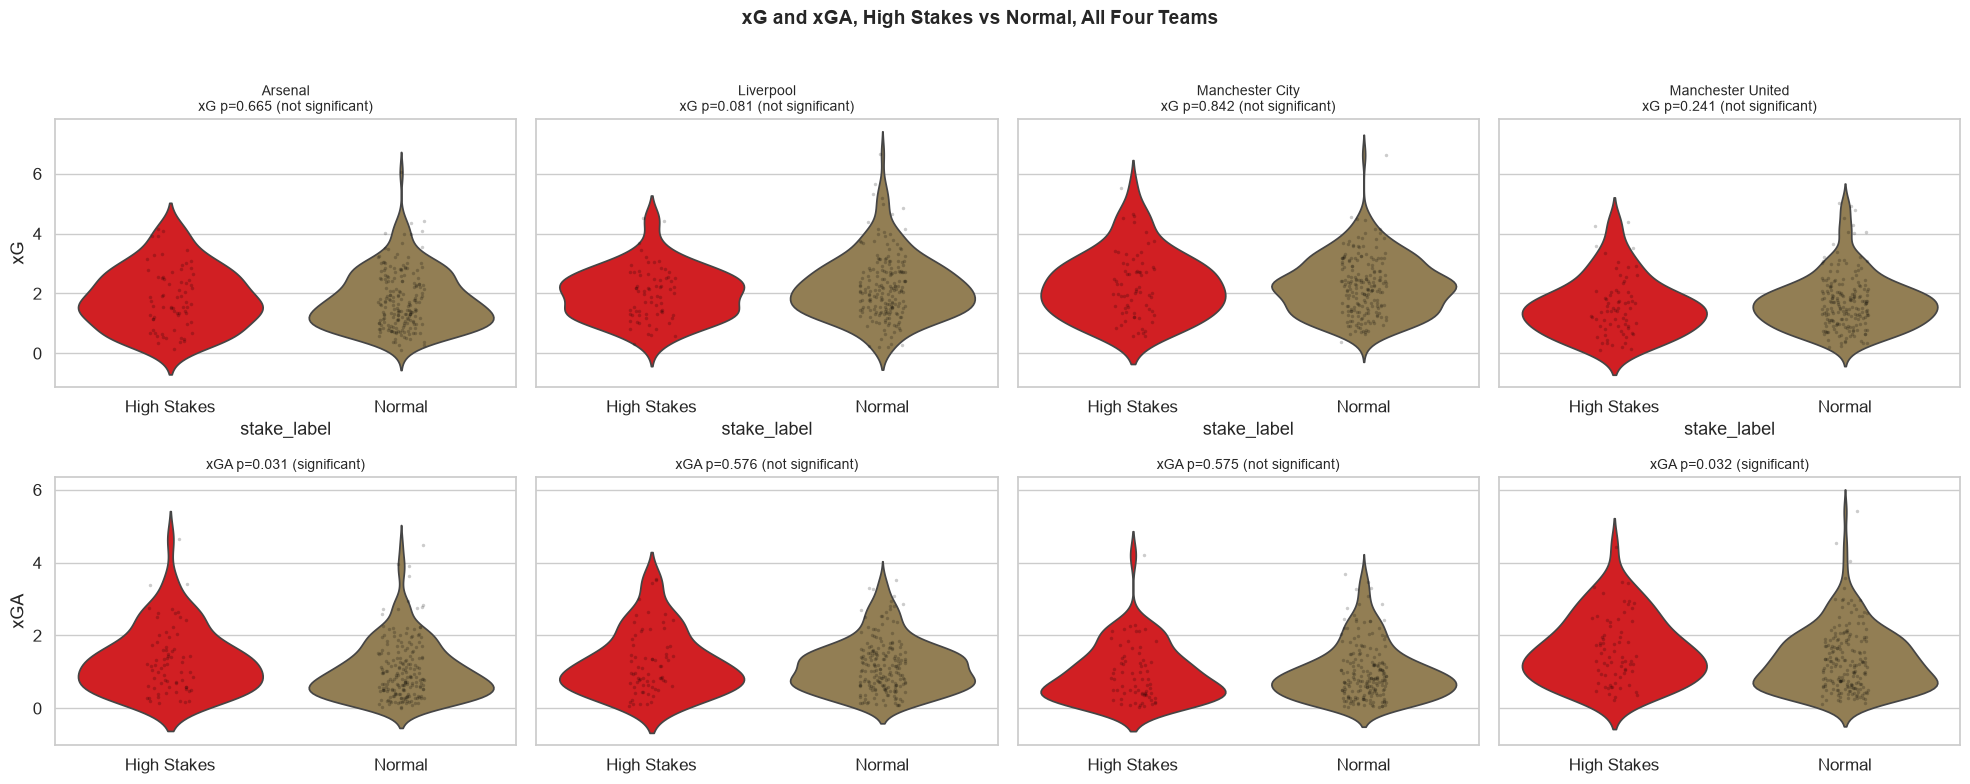

In [10]:
fig, axes = plt.subplots (2, 4, figsize = (20, 8), sharey = 'row')

for col,team in enumerate(TITLE_TEAMS):
    t = df[df['team'] == team].copy()
    t['stake_label'] = t['is_high_stakes_retro'].map({True: 'High Stakes', False: 'Normal'})

    ax_xg = axes[0,col]
    sns.violinplot(data=t, x = 'stake_label', y='xG', order = ['High Stakes', 'Normal'],
                  palette = STAKES_PALETTE, inner = None, ax = ax_xg)
    sns.stripplot(data=t, x= 'stake_label', y='xG', order = ['High Stakes', 'Normal'],
                 color = 'black', alpha = 0.2, size = 2.5, jitter = True, ax = ax_xg)
    p=ttest_df.loc[team,'xG_p']
    tag = 'significant' if p<0.05 else 'not significant'
    ax_xg.set_title(f'{team}\nxG p={p:.3f} ({tag})', fontsize=10)

    ax_xga = axes[1,col]
    sns.violinplot(data=t, x='stake_label', y='xGA', order=['High Stakes', 'Normal'],
                   palette=STAKES_PALETTE, inner=None, ax=ax_xga)
    sns.stripplot(data=t, x = 'stake_label', y = 'xGA', order = ['High Stakes', 'Normal'],
                 color = 'black', alpha = 0.2, size = 2.5, jitter = True, ax = ax_xga)
    p=ttest_df.loc[team, 'xGA_p']
    tag = 'significant' if p< 0.05 else 'not significant'
    ax_xga.set_title(f'xGA p={p:.3f} ({tag})', fontsize=10)
    ax_xga.set_xlabel('')
    ax_xga.set_ylabel('xGA' if col == 0 else '')

fig.suptitle('xG and xGA, High Stakes vs Normal, All Four Teams', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Reading Chart C1

Arsenal's pattern is not unique. Manchester United shows almost the identical split: xG not significant (p=0.241), xGA significant (p=0.032), close to Arsenal's own 0.031. Manchester City and Liverpool show neither effect, both teams' xG and xGA p-values sit well above 0.05 in both directions.

The defence-softens-under-pressure finding generalises to one other team, not all three. Not an Arsenal-only quirk, but not a league-wide pattern either. It shows up in the two teams whose recent history includes sustained title disappointment (Arsenal) or decline (Manchester United), not in the two teams whose recent history includes actually winning titles (City, Liverpool). Worth flagging, not proof of anything causal, four teams is a small sample to draw a general conclusion from.

---
## Section D - Win Rate Decay

---
## Chart D1 - Win Rate, Normal vs High Stakes, All Four Teams

NB03's Chart C6 already noted that win rate is a blunter version of the PPG gap, since it throws away the difference between a draw and a loss. Same check, across all four teams.

In [11]:
# win rate per team, normal vs high-stakes-retro
win_rates = (
    df.groupby(['team','is_high_stakes_retro'])['points']
    .apply(lambda x: (x==3).mean())
    .unstack()
)
win_rates.columns = ['normal_winrate', 'highstakes_winrate']
win_rates['decay_pp'] = (win_rates['normal_winrate'] - win_rates['highstakes_winrate'])

print((win_rates*100).round(1))

                   normal_winrate  highstakes_winrate  decay_pp
team                                                           
Arsenal                      57.7                58.6      -0.9
Liverpool                    62.2                61.4       0.8
Manchester City              67.3                71.4      -4.1
Manchester United            48.0                47.1       0.8


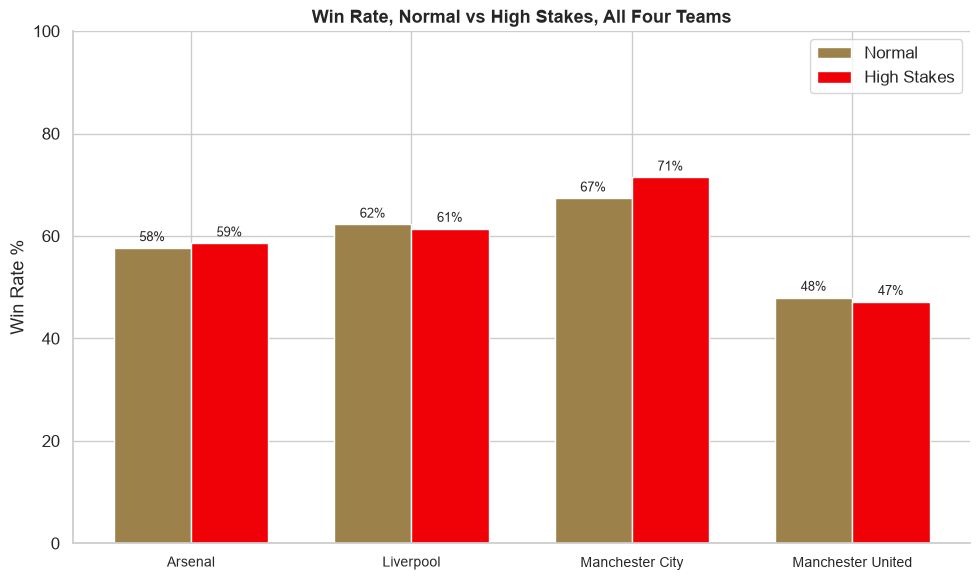

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

x=np.arange(len(TITLE_TEAMS))
width = 0.35

normal_vals = [win_rates.loc[t, 'normal_winrate'] * 100 for t in TITLE_TEAMS]
hs_vals = [win_rates.loc[t, 'highstakes_winrate'] * 100 for t in TITLE_TEAMS]

bars1 = ax.bar(x-width/2, normal_vals, width, label='Normal', color='#9C824A')
bars2 = ax.bar(x+width/2, hs_vals, width, label='High Stakes', color = '#EF0107')

ax.bar_label(bars1, fmt = '%.0f%%', padding = 3, fontsize = 9)
ax.bar_label(bars2, fmt = '%.0f%%', padding = 3, fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels(TITLE_TEAMS, fontsize=10)
ax.set_ylabel('Win Rate %')
ax.set_ylim(0, 100)
ax.set_title('Win Rate, Normal vs High Stakes, All Four Teams', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reading Chart D1

The decay is small everywhere and does not even point the same direction for every team: Arsenal -0.9pp, Manchester City -4.1pp, Liverpool +0.8pp, Manchester United +0.8pp. City is the only team with a real drop by this measure, and it is the team that came out best on the PPG-based Pressure Resilience Index in Chart B2. A reminder that win rate and PPG gap are not measuring quite the same thing, since win rate cannot tell a costly draw apart from a comfortable one. This is why NB03 kept PPG as the primary metric and treated win rate as a supporting chart, not the other way round.

---
## Section E - Flat-Track Bullies vs Big-Game Changers

---
## Chart E1 - Pressure PPG Gap by Opponent Tier

A team's high-stakes matches naturally include more games against strong opposition, since derbies and rivalries carry extra stakes weight (see RIVALRIES in NB02). Before concluding anything about pressure specifically, this checks a more precise question: does the size of the pressure gap itself change depending on whether the opponent is a Big 6 side, not just whether Big 6 opponents are harder in general, which they always are, stakes or not.

In [13]:
# per team: PPG gap (high-stakes-retro minus normal), split by Big6 vs Rest opponent

tier_rows = []
for team in TITLE_TEAMS:
    t = df[df['team'] == team].copy()
    t['tier'] = t['opponent'].isin(BIG6).map({True: 'Big6', False: 'Rest'})
    piv = t.groupby(['tier', 'is_high_stakes_retro'])['points'].mean().unstack()
    piv.columns = ['normal', 'high_stakes']
    piv['gap'] = piv['high_stakes'] - piv['normal']
    piv['team'] = team
    tier_rows.append(piv.reset_index())

tier_df = pd.concat(tier_rows, ignore_index=True)
print(tier_df.round(3).to_string(index=False))

tier  normal  high_stakes    gap              team
Big6   1.522        1.542  0.020           Arsenal
Rest   2.080        2.152  0.072           Arsenal
Big6   1.766        1.478 -0.288         Liverpool
Rest   2.208        2.277  0.069         Liverpool
Big6   1.620        1.700  0.080   Manchester City
Rest   2.384        2.520  0.136   Manchester City
Big6   1.349        1.259 -0.090 Manchester United
Rest   1.758        1.977  0.219 Manchester United


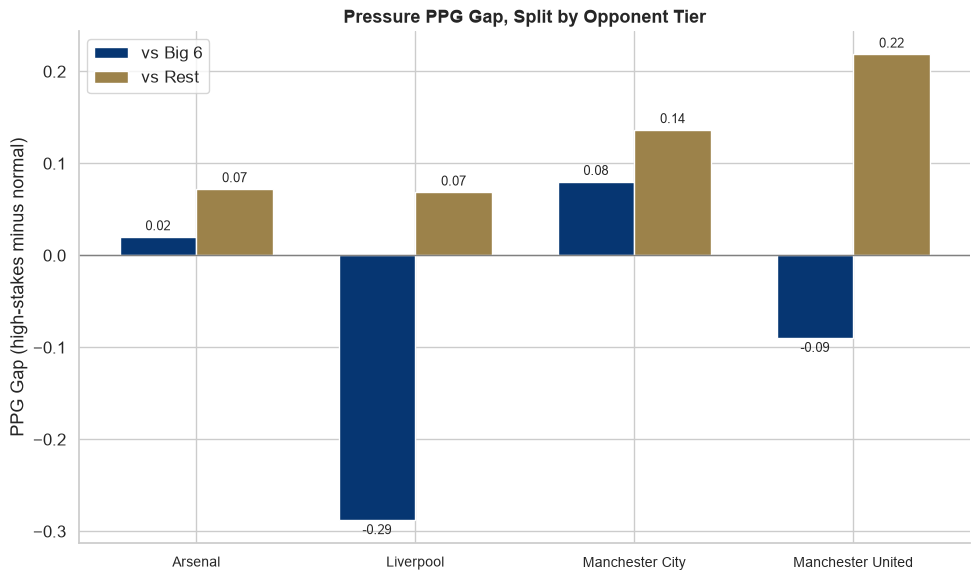

In [14]:
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(TITLE_TEAMS))
width = 0.35

big6_gap = [tier_df[(tier_df['team'] == t) & (tier_df['tier'] == 'Big6')]['gap'].values[0] for t in TITLE_TEAMS]
rest_gap = [tier_df[(tier_df['team'] == t) & (tier_df['tier'] == 'Rest')]['gap'].values[0] for t in TITLE_TEAMS]

bars1 = ax.bar(x-width/2, big6_gap, width, label = 'vs Big 6', color = '#063672')
bars2 = ax.bar(x+width/2, rest_gap, width, label = 'vs Rest', color = '#9C824A')

ax.bar_label(bars1, fmt='%.2f', padding = 3, fontsize = 9)
ax.bar_label(bars2, fmt = '%.2f', padding = 3, fontsize = 9)
ax.axhline(y=0, color = 'grey', linewidth = 1)

ax.set_xticks(x)
ax.set_xticklabels(TITLE_TEAMS, fontsize = 10)
ax.set_ylabel('PPG Gap (high-stakes minus normal)')
ax.set_title('Pressure PPG Gap, Split by Opponent Tier', fontsize = 13, fontweight = 'bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reading Chart E1

Against Rest opponents, every team's high-stakes PPG is flat or slightly better than normal, none of the four teams are flat-track bullies who only turn it on when nothing is at stake. The interesting split is on the Big 6 side. Liverpool's gap against Big 6 opponents is sharply negative (-0.29), Manchester United's is also negative (-0.09). Arsenal and Manchester City are both close to flat against Big 6 (+0.02, +0.08).

The struggling-specifically-in-big-games-against-big-opponents pattern belongs to Liverpool and United here, not Arsenal. A different answer than Chart B1's PPG-gap-by-season alone would suggest, and a good example of why one summary metric rarely tells the whole story.

---
## Confounding Variables - What This Comparison Cannot Settle

Same spirit as NB03's confounders section, with one addition specific to comparing across teams.

Opponent quality and squad composition changed differently for each of these four clubs over seven seasons: City's peak years, Liverpool's title followed by a rebuild, United's decline, Arsenal's rise. High stakes does not mean the same competitive context for every team at every point in this window. The intensity check earlier in this notebook already showed this directly for Manchester United, whose retro high-stakes bucket sits at a much lower absolute stakes_intensity in its decline seasons (0.492 in 23-24, 0.364 in 24-25) than the other three teams typically show.

Sample sizes get thin once slicing by team, season and opponent tier at once. Some of the Chart E1 splits are averaging over single-digit match counts. Small samples mean more room for one or two results to swing a mean.

None of the differences described in this notebook have been through a significance test that accounts for multiple teams and multiple comparisons at once. NB05 is where that happens properly, this notebook is descriptive, not confirmatory.

---
## Key Findings Summary

In [15]:
print('=' * 70)
print('KEY FINDINGS - Comparative Multi-Team EDA')
print('=' * 70)
print()
print('1. THE BOTTLE GAP ISN\'T UNIQUE TO ARSENAL, BUT ITS SHAPE IS')
print('   Every team has seasons with a negative high-stakes PPG gap.')
print('   Manchester City is the only team net positive across contention')
print('   seasons (+0.071). Liverpool is the most negative (-0.182), worse')
print('   than Arsenal (-0.091). What is specific to Arsenal is that its two')
print('   negative seasons line up exactly with its two named bottle seasons.')
print()
print('2. THE XG-STABLE / XGA-SOFT SPLIT GENERALISES TO ONE OTHER TEAM')
for team in TITLE_TEAMS:
    row = ttest_df.loc[team]
    print(f'   {team:20s} xG p={row.xG_p:.3f}   xGA p={row.xGA_p:.3f}')
print('   Arsenal and Manchester United both show a flat xG / significant')
print('   xGA split. City and Liverpool show neither.')
print()
print('3. WIN RATE IS STILL A BLUNTER MEASURE THAN PPG GAP')
print('   Decay is small and inconsistent in direction across all four teams.')
print()
print('4. THE BIG-GAME PROBLEM BELONGS TO LIVERPOOL AND UNITED, NOT ARSENAL')
print('   Liverpool (-0.29) and Manchester United (-0.09) show a real drop in')
print('   high-stakes PPG specifically against Big 6 opponents. Arsenal (+0.02)')
print('   and Manchester City (+0.08) do not.')
print()
print('5. CONFOUNDERS ACKNOWLEDGED - see section above')
print()
print('Next -> NB05: significance testing across teams (does not rely on eyeballing p-values one at a time)')

KEY FINDINGS - Comparative Multi-Team EDA

1. THE BOTTLE GAP ISN'T UNIQUE TO ARSENAL, BUT ITS SHAPE IS
   Every team has seasons with a negative high-stakes PPG gap.
   Manchester City is the only team net positive across contention
   seasons (+0.071). Liverpool is the most negative (-0.182), worse
   than Arsenal (-0.091). What is specific to Arsenal is that its two
   negative seasons line up exactly with its two named bottle seasons.

2. THE XG-STABLE / XGA-SOFT SPLIT GENERALISES TO ONE OTHER TEAM
   Arsenal              xG p=0.665   xGA p=0.031
   Liverpool            xG p=0.081   xGA p=0.576
   Manchester City      xG p=0.842   xGA p=0.575
   Manchester United    xG p=0.241   xGA p=0.032
   Arsenal and Manchester United both show a flat xG / significant
   xGA split. City and Liverpool show neither.

3. WIN RATE IS STILL A BLUNTER MEASURE THAN PPG GAP
   Decay is small and inconsistent in direction across all four teams.

4. THE BIG-GAME PROBLEM BELONGS TO LIVERPOOL AND UNITED, N